# EXP-005 — Hierarchical 2/4/6-mer Logistic Regression

**Статус:** run_001 завершён; метрики и решение сохранены.

**Гипотеза.** L2 logistic regression сможет обучить вклад уровней
`2-mer + 4-mer + 6-mer` и превзойти фиксированный hierarchical
lookup из EXP-003 на новых contig.

**Меняем только estimator:** фиксированная posterior-формула
EXP-003 → обучаемая логистическая регрессия. Окно, target, split,
ориентация и категории остаются прежними.

Этот notebook специально разбит на маленькие шаги. Не используйте
**Run All**: выполняйте ячейки сверху вниз и проверяйте вывод каждой.


## Карта notebook

1. Проверить окружение и неизменный data contract.
2. Посчитать **только train** категории `2/4/6-mer`.
3. Проверить sparse one-hot: 4 371 столбец, три активных признака.
4. Построить train-contig folds и показать точный `C`-grid.
5. Остановиться у первого checkpoint — до него модель не обучается.
6. Вручную запустить train-only CV и выбрать `C` механическим правилом.
7. Вручную обучить один final model на полном train.
8. Только после фиксации `C` открыть validation и сравнить с EXP-003.
9. Решение и артефакты сохранить отдельной последней ячейкой.

> Validation намеренно расположен **после** выбора `C` и full-train
> fit. Так параметры нельзя незаметно подобрать по финальным метрикам.


In [1]:
from pathlib import Path
import json
import platform
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
    if (candidate / "README.md").is_file()
    and (candidate / "src/ml_project").is_dir()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ml_project.epic_baseline import load_baseline_sequences
from ml_project.epic_data import ensure_prepared_split
from ml_project.epic_experiment import (
    ExperimentSpec,
    build_run_record,
    save_run_record,
)
from ml_project.epic_kmer import (
    KmerLookupConfig,
    evaluate_kmer_lookup,
    fit_kmer_lookup,
    split_kmer_counts,
)
from ml_project.epic_kmer_logistic import (
    HierarchicalKmerLogisticConfig,
    aggregate_binary_likelihood,
    cross_validate_hierarchical_kmer_logistic,
    evaluate_category_scores,
    fit_hierarchical_kmer_logistic,
    hierarchical_kmer_design,
    make_balanced_contig_folds,
    select_regularization,
    summarise_cv,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 60)

display(pd.Series({
    "python": platform.python_version(),
    "executable": sys.executable,
    "project_root": str(PROJECT_ROOT),
    "notebook_state": "prepared / unexecuted",
}, name="value").to_frame())


,value
python,3.12.14
executable,C:\ML_Progs\Runtimes\Miniforge3\envs\epic-eda\...
project_root,D:\Projects\EPIC\EPIC
notebook_state,prepared / unexecuted


## 1. Протокол до обучения

Главный reference — EXP-003, 6-mer lookup:

- validation AP `0.0016005373755008387`;
- EPIC Spearman `0.09718557212273755`.

EXP-005 принимается только при выполнении всех условий:

- относительный AP gain не меньше 1%;
- EPIC Spearman не ниже EXP-003;
- AP выше reference минимум на 2 из 3 validation-contig.

`C` выбирается без validation: среди сошедшихся вариантов берём
самый маленький `C` в пределах 1% от лучшего mean train-CV AP,
если его mean CV Spearman не хуже Spearman лучшего по AP варианта.


In [2]:
EXPERIMENT_ID = "EXP-005"
RUN_NAME = "run_001"
NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks/experiments/EXP-005_hierarchical_6mer_logistic.ipynb"
)
ARTIFACT_DIR = (
    PROJECT_ROOT / "artifacts/experiments" / EXPERIMENT_ID / RUN_NAME
)
PLOT_DIR = ARTIFACT_DIR / "plots"

SPEC = ExperimentSpec(
    experiment_id=EXPERIMENT_ID,
    title="Hierarchical 2/4/6-mer Logistic Regression",
    hypothesis=(
        "Train-only tuned L2 logistic regression over hierarchical "
        "2/4/6-mer one-hot features improves on EXP-003 lookup"
    ),
    changed_variable=(
        "fixed posterior lookup -> L2 logistic regression; sequence "
        "window and hierarchy remain 2/4/6-mer"
    ),
    success_criterion=(
        "relative validation AP gain >= 1%; candidate EPIC Spearman "
        ">= EXP-003; AP improves on at least 2 of 3 validation contigs"
    ),
    seed=42,
)
CONFIG = HierarchicalKmerLogisticConfig()
display(pd.Series(CONFIG.to_dict(), name="fixed_value").to_frame())


,fixed_value
ks,"[2, 4, 6]"
C_grid,"[0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1..."
penalty,l2
solver,lbfgs
max_iter,500
tol,0.0
threads,2
seed,42
balance_classes,True
cv_folds,3


## 2. Неизменный data contract

Загружается `contig_holdout_v1`. Обе цепи одного contig остаются
вместе. Target равен `int(pooled_count > 0)`. Test target не
существует и официальный test нигде в эксперименте не читается.


In [3]:
split = ensure_prepared_split(PROJECT_ROOT)
assert split.config.split_version == "contig_holdout_v1"
display(split.contig_assignment.sort_values(["split", "contig"]))
display(split.summary)


,contig,split,source_split
12,NC_064037.1,test,test
13,NC_064044.1,test,test
14,NC_064046.1,test,test
1,NC_064035.1,train,train
2,NC_064036.1,train,train
3,NC_064038.1,train,train
4,NC_064039.1,train,train
5,NC_064040.1,train,train
8,NC_064043.1,train,train
9,NC_064045.1,train,train


,split,contigs,intervals_both_strands,whitelist_bp,position_strand_count,percent_of_all_positions,positive_positions,negative_positions,positive_percent
0,train,9,168998,114032080,228064160,59.316784,170443.0,227893717.0,0.074735
1,validation,3,60386,41903743,83807486,21.797334,56205.0,83751281.0,0.067064
2,test,3,54846,36306695,72613390,18.885882,NaN,NaN,NaN


In [4]:
started = time.monotonic()
sequences, fasta_alphabet = load_baseline_sequences(split)
fasta_seconds = time.monotonic() - started
display(pd.Series({
    "contigs_loaded": len(sequences),
    "alphabet": str(fasta_alphabet),
    "seconds": fasta_seconds,
}, name="value").to_frame())


,value
contigs_loaded,47
alphabet,"{'A': 54173800, 'C': 39020211, 'G': 38944862, ..."
seconds,5.218


## 3. Точный подсчёт train — ещё без модели

Следующая ячейка проходит по полному train и считает категории.
Это feature preparation, не обучение. Ожидаемое время на текущей
машине — около 20 секунд. Validation пока не открывается.


In [5]:
started = time.monotonic()
train_counts = split_kmer_counts(
    split,
    sequences,
    "train",
    ks=CONFIG.ks,
)
train_count_seconds = time.monotonic() - started
print(f"Full train counted in {train_count_seconds:.2f} s")


Full train counted in 13.92 s


In [6]:
train_population = (
    train_counts.totals.groupby("k")["total_positions"].sum()
)
train_positive_population = len(train_counts.positives)
audit = pd.DataFrame({
    "positions": train_population,
    "positive_positions": train_positive_population,
    "prevalence": train_positive_population / train_population,
})
display(audit)
assert train_population.nunique() == 1
assert int(train_population.iloc[0]) == 228_064_160
assert train_positive_population == 170_443


,positions,positive_positions,prevalence
k,,,
2,228064160,170443,0.000747
4,228064160,170443,0.000747
6,228064160,170443,0.000747


## 4. Признаки: обучаемая иерархия `2 + 4 + 6`

Для каждого канонического 6-mer включаются три столбца:

```text
ACGTCA → k2=CA + k4=GTCA + k6=ACGTCA
```

Полный словарь содержит `17 + 257 + 4097 = 4371` столбец. Это
полный sparse one-hot, а не порядковые числа. Благодаря общим
2/4-mer столбцам редкие 6-mer могут опираться на устойчивый suffix,
но силу этого эффекта теперь обучает LR.

Консервативное правило неоднозначности: если 6-mer равен `N/edge`,
активируется `N/edge` на каждом уровне. `strand` остаётся только в
ключе; последовательность уже ориентирована extractor-ом.


In [7]:
design = hierarchical_kmer_design(CONFIG)
display(pd.Series({
    "possible_6mer_categories": design.matrix.shape[0],
    "feature_columns": design.matrix.shape[1],
    "nonzero_values": design.matrix.nnz,
    "active_features_per_category": design.matrix.getnnz(axis=1).min(),
}, name="value").to_frame())
assert design.matrix.shape == (4097, 4371)
assert np.all(design.matrix.getnnz(axis=1) == 3)


,value
possible_6mer_categories,4097
feature_columns,4371
nonzero_values,12291
active_features_per_category,3


In [8]:
examples = design.category_table.loc[
    design.category_table["max_category"].isin(
        ["AAAAAA", "ACGTCA", "TTTTTT", "N/edge"]
    )
]
display(examples)
display(design.feature_table.groupby("level_k").size().rename("columns"))


,max_category_code,max_category,kmer_2_code,kmer_2,kmer_4_code,kmer_4,kmer_6_code,kmer_6
0,0,AAAAAA,0,AA,0,AAAA,0,AAAAAA
436,436,ACGTCA,4,CA,180,GTCA,436,ACGTCA
4095,4095,TTTTTT,15,TT,255,TTTT,4095,TTTTTT
4096,4096,N/edge,16,N/edge,256,N/edge,4096,N/edge


level_k
2      17
4     257
6    4097
Name: columns, dtype: int64

## 5. Как 228 млн строк помещаются в память

Все позиции одного 6-mer имеют одинаковые признаки. Поэтому binary
likelihood можно **точно**, без sampling, представить двумя строками
на категорию: negative и positive, а multiplicity передать через
`sample_weight`.

Максимум получается `4097 × 2 = 8194` агрегированные строки. Это
не приближение: оптимизируется та же weighted logistic loss, что и
при физическом повторении всех train-позиций.


In [9]:
aggregate_preview = aggregate_binary_likelihood(
    train_counts,
    design,
    balance_classes=CONFIG.balance_classes,
)
display(aggregate_preview.rows.head(10))
display(pd.Series({
    "aggregate_rows": len(aggregate_preview.rows),
    "represented_positions": int(
        aggregate_preview.rows["population_count"].sum()
    ),
    "represented_positives": int(
        aggregate_preview.rows.loc[
            aggregate_preview.rows["target"] == 1,
            "population_count",
        ].sum()
    ),
    "sparse_shape": str(aggregate_preview.matrix.shape),
    "sparse_nnz": aggregate_preview.matrix.nnz,
}, name="value").to_frame())
display(
    aggregate_preview.rows.groupby("target")[[
        "population_count", "sample_weight"
    ]].sum()
)


,category_code,category,target,population_count,class_multiplier,sample_weight
0,0,AAAAAA,0,597312,0.500374,298879.366512
1,0,AAAAAA,1,165,669.033519,110390.530559
2,1,AAAAAC,0,217219,0.500374,108690.729659
3,1,AAAAAC,1,29,669.033519,19401.972038
4,2,AAAAAG,0,241249,0.500374,120714.715746
5,2,AAAAAG,1,83,669.033519,55529.782039
6,3,AAAAAT,0,332337,0.500374,166292.778361
7,3,AAAAAT,1,30,669.033519,20071.005556
8,4,AAAACA,0,261860,0.500374,131027.923288
9,4,AAAACA,1,514,669.033519,343883.228528


,value
aggregate_rows,8194
represented_positions,228064160
represented_positives,170443
sparse_shape,"(8194, 4371)"
sparse_nnz,24582


,population_count,sample_weight
target,,
0,227893717,114032080.0
1,170443,114032080.0


## 6. Внутренняя validation только внутри train

Девять train-contig делятся на три folds целиком, жадно балансируясь
по числу position-strand. Обе цепи contig всегда остаются вместе.
Внешние три validation-contig здесь не используются.


In [10]:
fold_assignment = make_balanced_contig_folds(
    train_counts,
    k=CONFIG.max_k,
    n_splits=CONFIG.cv_folds,
)
display(fold_assignment)
display(
    fold_assignment.groupby("fold")[["positions", "positives"]]
    .sum()
    .assign(prevalence=lambda frame: frame.positives / frame.positions)
)
assert fold_assignment["contig"].nunique() == 9
assert fold_assignment.groupby("contig")["fold"].nunique().max() == 1


,contig,positions,positives,fold,prevalence
0,NC_064035.1,33456756,30987,0,0.000926
1,NC_064043.1,24039838,19558,0,0.000814
2,NC_064048.1,17926958,10888,0,0.000607
3,NC_064036.1,31610378,26323,1,0.000833
4,NC_064038.1,25217952,14793,1,0.000587
5,NC_064045.1,20367114,15184,1,0.000746
6,NC_064039.1,27686596,21975,2,0.000794
7,NC_064040.1,26051020,19067,2,0.000732
8,NC_064047.1,21707548,11668,2,0.000538


,positions,positives,prevalence
fold,,,
0,75423552,61433,0.000815
1,77195444,56300,0.000729
2,75445164,52710,0.000699


## 7. Solver и гиперпараметр

Используется `LogisticRegression(penalty="l2", solver="lbfgs")`.
У `lbfgs` нет пользовательского learning rate: длину шага определяет
сам алгоритм. Единственный подбираемый model-параметр — `C`, обратная
сила L2-регуляризации.

Grid содержит 13 заранее заданных значений от `1e-4` до `100`.
Это всего 39 fits (`13 C × 3 folds`) на матрице не более 8194 строк.
Optuna здесь не нужна: одномерный grid прозрачен и проверяет весь
диапазон.

У `lbfgs` нет эпох, поэтому честного графика loss-by-epoch не будет.
Вместо него после CV строятся balanced log-loss, AP, Spearman,
`n_iter` и convergence по каждому `C`.


In [11]:
model_plan = pd.DataFrame({"C": CONFIG.C_grid})
model_plan["regularization_strength_1_over_C"] = 1 / model_plan["C"]
display(model_plan)
print("Planned fits:", len(CONFIG.C_grid) * CONFIG.cv_folds)
print("No model has been fitted yet.")


,C,regularization_strength_1_over_C
0,0.0001,10000.000000
1,0.0003,3333.333333
2,0.0010,1000.000000
3,0.0030,333.333333
4,0.0100,100.000000
5,0.0300,33.333333
6,0.1000,10.000000
7,0.3000,3.333333
8,1.0000,1.000000
9,3.0000,0.333333


Planned fits: 39
No model has been fitted yet.


# ⛔ CHECKPOINT 1 — первое обучение ниже

До этой точки выполнены только загрузка, точный подсчёт, построение
признаков и folds. **Ни одной логистической регрессии ещё нет.**

Перед следующей ячейкой вместе проверяем:

- почему активны три признака;
- почему агрегация точная;
- зачем нужен class balancing;
- почему validation ещё не открывался;
- почему подбирается `C`, но не learning rate.


## 8. TRAINING STEP 1 — train-only cross-validation

Следующая ячейка действительно обучает 39 моделей. Запускайте её
только после совместной проверки checkpoint. Она не читает внешний
validation и не выбирает решение EXP-005.


In [15]:
CONFIG = HierarchicalKmerLogisticConfig(max_iter=2000)

display(
    pd.Series(CONFIG.to_dict(), name="updated_value").to_frame()
)

,updated_value
ks,"[2, 4, 6]"
C_grid,"[0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1..."
penalty,l2
solver,lbfgs
max_iter,2000
tol,0.0
threads,2
seed,42
balance_classes,True
cv_folds,3


In [16]:
started = time.monotonic()
cv_results = cross_validate_hierarchical_kmer_logistic(
    train_counts,
    fold_assignment,
    config=CONFIG,
)
cv_seconds = time.monotonic() - started
print(f"Train-only CV completed in {cv_seconds:.2f} s")
display(cv_results)


Train-only CV completed in 30.78 s


,C,fold,validation_contigs,segment,variant,average_precision,epic_spearman,population_log_loss,balanced_log_loss,positions,positives,prevalence,unique_score_levels,iterations,converged,fit_seconds,warnings
0,0.0001,0,"NC_064035.1,NC_064043.1,NC_064048.1","NC_064035.1,NC_064043.1,NC_064048.1",hierarchical_2_4_6mer_lr,0.001943,0.076188,0.628153,0.630685,75423552,61433,0.000815,4097,187,True,0.125,
1,0.0001,1,"NC_064036.1,NC_064038.1,NC_064045.1","NC_064036.1,NC_064038.1,NC_064045.1",hierarchical_2_4_6mer_lr,0.001663,0.081952,0.627116,0.634567,77195444,56300,0.000729,4097,182,True,0.125,
2,0.0001,2,"NC_064039.1,NC_064040.1,NC_064047.1","NC_064039.1,NC_064040.1,NC_064047.1",hierarchical_2_4_6mer_lr,0.001685,0.080206,0.628912,0.629128,75445164,52710,0.000699,4097,182,True,0.125,
3,0.0003,0,"NC_064035.1,NC_064043.1,NC_064048.1","NC_064035.1,NC_064043.1,NC_064048.1",hierarchical_2_4_6mer_lr,0.001950,0.077606,0.625777,0.630248,75423552,61433,0.000815,4097,295,True,0.203,
4,0.0003,1,"NC_064036.1,NC_064038.1,NC_064045.1","NC_064036.1,NC_064038.1,NC_064045.1",hierarchical_2_4_6mer_lr,0.001675,0.083858,0.624860,0.634210,77195444,56300,0.000729,4097,291,True,0.203,
5,0.0003,2,"NC_064039.1,NC_064040.1,NC_064047.1","NC_064039.1,NC_064040.1,NC_064047.1",hierarchical_2_4_6mer_lr,0.001694,0.082035,0.626585,0.628732,75445164,52710,0.000699,4097,273,True,0.188,
6,0.0010,0,"NC_064035.1,NC_064043.1,NC_064048.1","NC_064035.1,NC_064043.1,NC_064048.1",hierarchical_2_4_6mer_lr,0.001946,0.078191,0.624845,0.631116,75423552,61433,0.000815,4097,459,True,0.296,
7,0.0010,1,"NC_064036.1,NC_064038.1,NC_064045.1","NC_064036.1,NC_064038.1,NC_064045.1",hierarchical_2_4_6mer_lr,0.001675,0.085048,0.624012,0.635094,77195444,56300,0.000729,4097,456,True,0.297,
8,0.0010,2,"NC_064039.1,NC_064040.1,NC_064047.1","NC_064039.1,NC_064040.1,NC_064047.1",hierarchical_2_4_6mer_lr,0.001694,0.083049,0.625686,0.629627,75445164,52710,0.000699,4097,461,True,0.328,
9,0.0030,0,"NC_064035.1,NC_064043.1,NC_064048.1","NC_064035.1,NC_064043.1,NC_064048.1",hierarchical_2_4_6mer_lr,0.001941,0.078322,0.624669,0.631923,75423552,61433,0.000815,4097,684,True,0.454,


In [19]:
cv_summary = summarise_cv(cv_results)
display(cv_summary.style.format({
    "C": "{:.4g}",
    "mean_average_precision": "{:.9f}",
    "std_average_precision": "{:.9f}",
    "mean_epic_spearman": "{:.6f}",
    "std_epic_spearman": "{:.6f}",
    "mean_balanced_log_loss": "{:.6f}",
    "total_fit_seconds": "{:.2f}",
}))
nonconverged = cv_summary.loc[
    ~cv_summary["all_folds_converged"]
].copy()

display(nonconverged)

best_cv_row = cv_summary.loc[
    cv_summary["mean_average_precision"].idxmax()
]

assert bool(best_cv_row["all_folds_converged"]), (
    "Лучший по AP вариант не сошёлся."
)

best_C = float(best_cv_row["C"])

left_neighbour = cv_summary.loc[
    cv_summary["C"] < best_C
].iloc[-1]

right_neighbour = cv_summary.loc[
    cv_summary["C"] > best_C
].iloc[0]

assert bool(left_neighbour["all_folds_converged"])
assert bool(right_neighbour["all_folds_converged"])

print("Лучший C и его соседи сошлись.")
print("Несошедшиеся слабее регуляризованные варианты исключены.")
print("Best CV C:", best_C)


,C,mean_average_precision,std_average_precision,mean_epic_spearman,std_epic_spearman,mean_balanced_log_loss,all_folds_converged,max_iterations,total_fit_seconds
0,0.0001,0.001763410,0.000155752,0.079449,0.002956,0.631460,True,187,0.38
1,0.0003,0.001773264,0.000153776,0.081166,0.003215,0.631063,True,295,0.59
2,0.001,0.001771419,0.000151098,0.082096,0.003526,0.631945,True,461,0.92
3,0.003,0.001768467,0.000150095,0.082373,0.003664,0.632750,True,684,1.30
4,0.01,0.001766709,0.000149820,0.082468,0.003757,0.633221,True,1088,1.83
5,0.03,0.001766194,0.000149687,0.082497,0.003787,0.633409,True,1370,2.19
6,0.1,0.001765924,0.000149720,0.082506,0.003796,0.633504,True,1355,2.05
7,0.3,0.001765845,0.000149731,0.082509,0.003796,0.633555,True,1671,2.45
8,1,0.001765820,0.000149722,0.082508,0.003796,0.633599,True,1651,2.47
9,3,0.001765810,0.000149724,0.082508,0.003796,0.633633,False,2000,2.72


,C,mean_average_precision,std_average_precision,mean_epic_spearman,std_epic_spearman,mean_balanced_log_loss,all_folds_converged,max_iterations,total_fit_seconds
9,3.0,0.001766,0.00015,0.082508,0.003796,0.633633,False,2000,2.718
10,10.0,0.001766,0.00015,0.082508,0.003796,0.633665,False,2000,2.906
11,30.0,0.001766,0.00015,0.082507,0.003796,0.633683,False,2000,2.938
12,100.0,0.001766,0.00015,0.082508,0.003796,0.633680,False,2000,2.875


Лучший C и его соседи сошлись.
Несошедшиеся слабее регуляризованные варианты исключены.
Best CV C: 0.0003


In [18]:
display(
    cv_summary.loc[
        ~cv_summary["all_folds_converged"],
        [
            "C",
            "mean_average_precision",
            "mean_epic_spearman",
            "max_iterations",
            "total_fit_seconds",
        ],
    ]
)

display(
    cv_results.loc[
        ~cv_results["converged"],
        [
            "C",
            "fold",
            "validation_contigs",
            "iterations",
            "warnings",
        ],
    ]
)

,C,mean_average_precision,mean_epic_spearman,max_iterations,total_fit_seconds
9,3.0,0.001766,0.082508,2000,2.718
10,10.0,0.001766,0.082508,2000,2.906
11,30.0,0.001766,0.082507,2000,2.938
12,100.0,0.001766,0.082508,2000,2.875


,C,fold,validation_contigs,iterations,warnings
27,3.0,0,"NC_064035.1,NC_064043.1,NC_064048.1",2000,lbfgs failed to converge after 2000 iteration(...
30,10.0,0,"NC_064035.1,NC_064043.1,NC_064048.1",2000,lbfgs failed to converge after 2000 iteration(...
32,10.0,2,"NC_064039.1,NC_064040.1,NC_064047.1",2000,lbfgs failed to converge after 2000 iteration(...
33,30.0,0,"NC_064035.1,NC_064043.1,NC_064048.1",2000,lbfgs failed to converge after 2000 iteration(...
35,30.0,2,"NC_064039.1,NC_064040.1,NC_064047.1",2000,lbfgs failed to converge after 2000 iteration(...
36,100.0,0,"NC_064035.1,NC_064043.1,NC_064048.1",2000,lbfgs failed to converge after 2000 iteration(...
38,100.0,2,"NC_064039.1,NC_064040.1,NC_064047.1",2000,lbfgs failed to converge after 2000 iteration(...


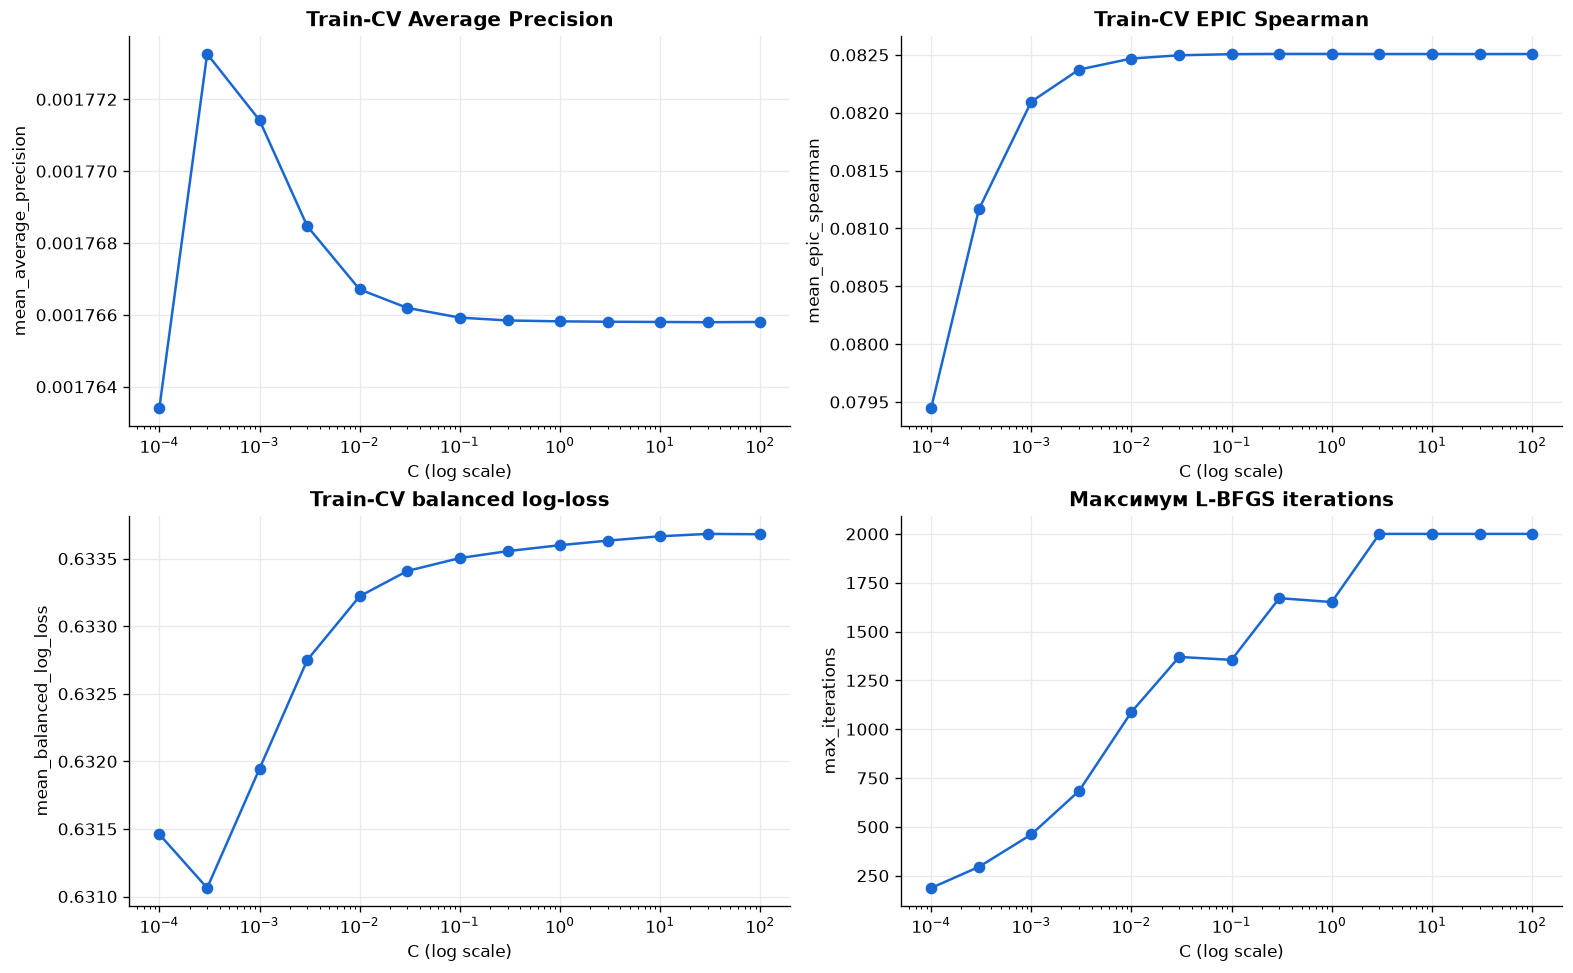

In [20]:
fig_cv, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
x = cv_summary["C"]
panels = [
    ("mean_average_precision", "Train-CV Average Precision"),
    ("mean_epic_spearman", "Train-CV EPIC Spearman"),
    ("mean_balanced_log_loss", "Train-CV balanced log-loss"),
    ("max_iterations", "Максимум L-BFGS iterations"),
]
for ax, (column, title) in zip(axes.flat, panels):
    ax.plot(x, cv_summary[column], marker="o", color="#1967D2")
    ax.set_xscale("log")
    ax.set_xlabel("C (log scale)")
    ax.set_ylabel(column)
    ax.set_title(title)
    ax.grid(color="#E8EAED")
plt.show()


In [21]:
selected_cv_row = select_regularization(
    cv_summary,
    relative_ap_tolerance=CONFIG.near_best_relative_ap,
)
SELECTED_C = float(selected_cv_row["C"])
display(selected_cv_row.rename("selected_value").to_frame())
print("Locked C:", SELECTED_C)


,selected_value
C,0.0003
mean_average_precision,0.001773
std_average_precision,0.000154
mean_epic_spearman,0.081166
std_epic_spearman,0.003215
mean_balanced_log_loss,0.631063
all_folds_converged,True
max_iterations,295
total_fit_seconds,0.594


Locked C: 0.0003


## 9. TRAINING STEP 2 — один full-train fit

`C` уже зафиксирован только по train-CV. Следующая ячейка обучает
ровно одну модель на всех девяти train-contig. Validation по-прежнему
не загружен и не посчитан.


In [22]:
final_fit = fit_hierarchical_kmer_logistic(
    train_counts,
    C=SELECTED_C,
    config=CONFIG,
    design=design,
)
display(final_fit.fit_report)
assert bool(final_fit.fit_report.iloc[0]["converged"])


,C,solver,penalty,tol,iterations,max_iter,converged,fit_seconds,aggregate_rows,features,represented_positions,represented_positives,intercept,warnings
0,0.0003,lbfgs,l2,1.000000e-08,319,2000,True,0.218,8194,4371,228064160,170443,-0.210863,


In [23]:
coefficient_levels = (
    final_fit.coefficient_table.groupby("level_k")
    .agg(
        features=("coefficient", "size"),
        l1_norm=("absolute_coefficient", "sum"),
        mean_absolute=("absolute_coefficient", "mean"),
        max_absolute=("absolute_coefficient", "max"),
    )
)
display(coefficient_levels)
display(
    final_fit.coefficient_table.nlargest(20, "absolute_coefficient")
)


,features,l1_norm,mean_absolute,max_absolute
level_k,,,,
2,17,7.815906,0.459759,1.195545
4,257,55.791316,0.217087,0.791496
6,4097,805.544127,0.196618,1.293791


,feature_index,level_k,category_code,category,feature_name,coefficient,absolute_coefficient
3004,3004,6,2730,GGGGGG,k6=GGGGGG,-1.293791,1.293791
1893,1893,6,1619,CGCCAT,k6=CGCCAT,1.211419,1.211419
4,4,2,4,CA,k2=CA,1.195545,1.195545
3405,3405,6,3131,TAATGT,k6=TAATGT,-0.935428,0.935428
2996,2996,6,2722,GGGGAG,k6=GGGGAG,-0.923241,0.923241
2885,2885,6,2611,GGATAT,k6=GGATAT,0.917031,0.917031
3008,3008,6,2734,GGGGTG,k6=GGGGTG,-0.910043,0.910043
4367,4367,6,4093,TTTTTC,k6=TTTTTC,-0.859186,0.859186
1105,1105,6,831,ATATTT,k6=ATATTT,-0.846857,0.846857
3855,3855,6,3581,TCTTTC,k6=TCTTTC,0.826384,0.826384


# ⛔ CHECKPOINT 2 — `C` и final model уже зафиксированы

Только теперь разрешено открыть validation. Если хочется изменить
признаки, grid, solver, weights или правило выбора `C`, этот run
прекращается и создаётся новый протокол — validation нельзя смотреть,
а затем переписывать EXP-005.


In [24]:
started = time.monotonic()
validation_counts = split_kmer_counts(
    split,
    sequences,
    "validation",
    ks=CONFIG.ks,
)
validation_count_seconds = time.monotonic() - started
print(f"Full validation counted in {validation_count_seconds:.2f} s")


Full validation counted in 5.12 s


In [25]:
lookup_config = KmerLookupConfig(
    ks=CONFIG.ks,
    smoothing="one_expected_positive",
)
lookup_fit = fit_kmer_lookup(train_counts, lookup_config)
lookup_evaluation = evaluate_kmer_lookup(validation_counts, lookup_fit)
reference_row = lookup_evaluation.metric_summary.loc[
    lookup_evaluation.metric_summary["k"] == 6
].iloc[0]
assert np.isclose(
    reference_row["average_precision"], 0.0016005373755008387
)
assert np.isclose(
    reference_row["epic_spearman"], 0.09718557212273755
)

candidate_evaluation = evaluate_category_scores(
    validation_counts,
    final_fit.category_scores,
    k=CONFIG.max_k,
    variant="hierarchical_2_4_6mer_lr",
)
candidate_row = candidate_evaluation.metric_summary.iloc[0]
metric_summary = pd.DataFrame([
    {
        "variant": "EXP-003 6-mer lookup",
        "average_precision": reference_row["average_precision"],
        "epic_spearman": reference_row["epic_spearman"],
    },
    {
        "variant": "EXP-005 hierarchical LR",
        "average_precision": candidate_row["average_precision"],
        "epic_spearman": candidate_row["epic_spearman"],
    },
])
display(metric_summary)


,variant,average_precision,epic_spearman
0,EXP-003 6-mer lookup,0.001601,0.097186
1,EXP-005 hierarchical LR,0.001606,0.097569


In [26]:
reference_contigs = lookup_evaluation.per_contig_metrics.loc[
    lookup_evaluation.per_contig_metrics["k"] == 6,
    ["segment_value", "average_precision", "epic_spearman"],
].rename(columns={
    "segment_value": "contig",
    "average_precision": "reference_average_precision",
    "epic_spearman": "reference_epic_spearman",
})
candidate_contig_rows = []
for contig in sorted(reference_contigs["contig"]):
    evaluated = evaluate_category_scores(
        validation_counts,
        final_fit.category_scores,
        k=CONFIG.max_k,
        contigs=(contig,),
        variant="hierarchical_2_4_6mer_lr",
    )
    row = evaluated.metric_summary.iloc[0]
    candidate_contig_rows.append({
        "contig": contig,
        "candidate_average_precision": row["average_precision"],
        "candidate_epic_spearman": row["epic_spearman"],
    })
per_contig_metrics = reference_contigs.merge(
    pd.DataFrame(candidate_contig_rows), on="contig", validate="one_to_one"
)
display(per_contig_metrics)


,contig,reference_average_precision,reference_epic_spearman,candidate_average_precision,candidate_epic_spearman
0,NC_064034.1,0.001717,0.109397,0.001725,0.109559
1,NC_064041.1,0.001381,0.120721,0.001386,0.121407
2,NC_064042.1,0.001655,0.115426,0.001658,0.116599


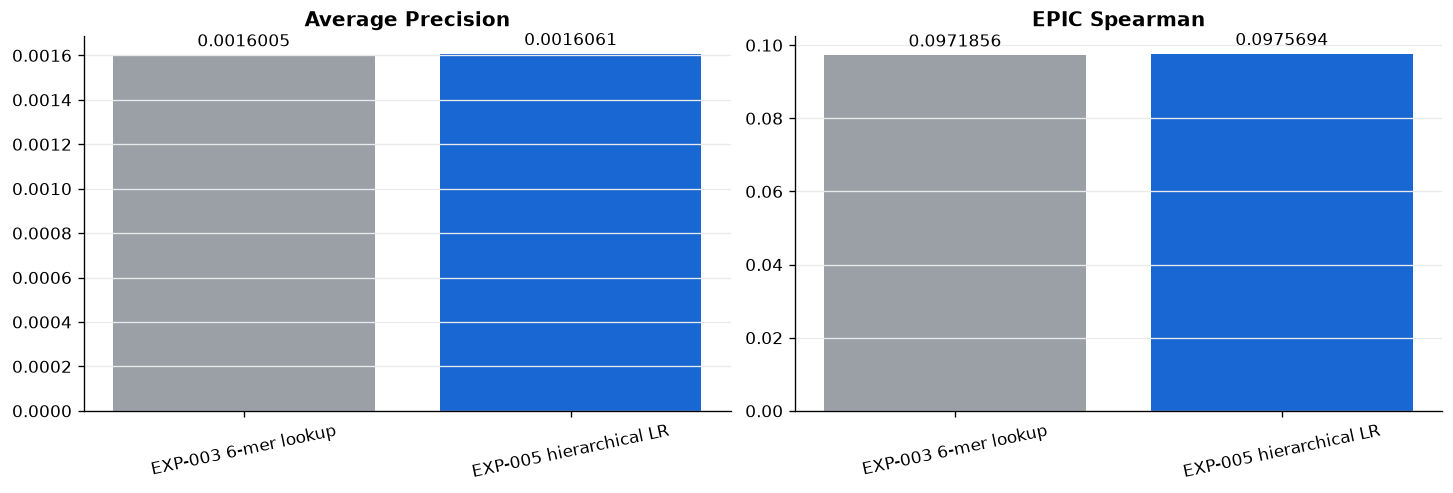

In [27]:
colors = ["#9AA0A6", "#1967D2"]
fig_metrics, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, metric, title in [
    (axes[0], "average_precision", "Average Precision"),
    (axes[1], "epic_spearman", "EPIC Spearman"),
]:
    bars = ax.bar(metric_summary["variant"], metric_summary[metric], color=colors)
    ax.bar_label(bars, fmt="%.7f", padding=3)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=12)
    ax.grid(axis="y", color="#E8EAED")
plt.show()


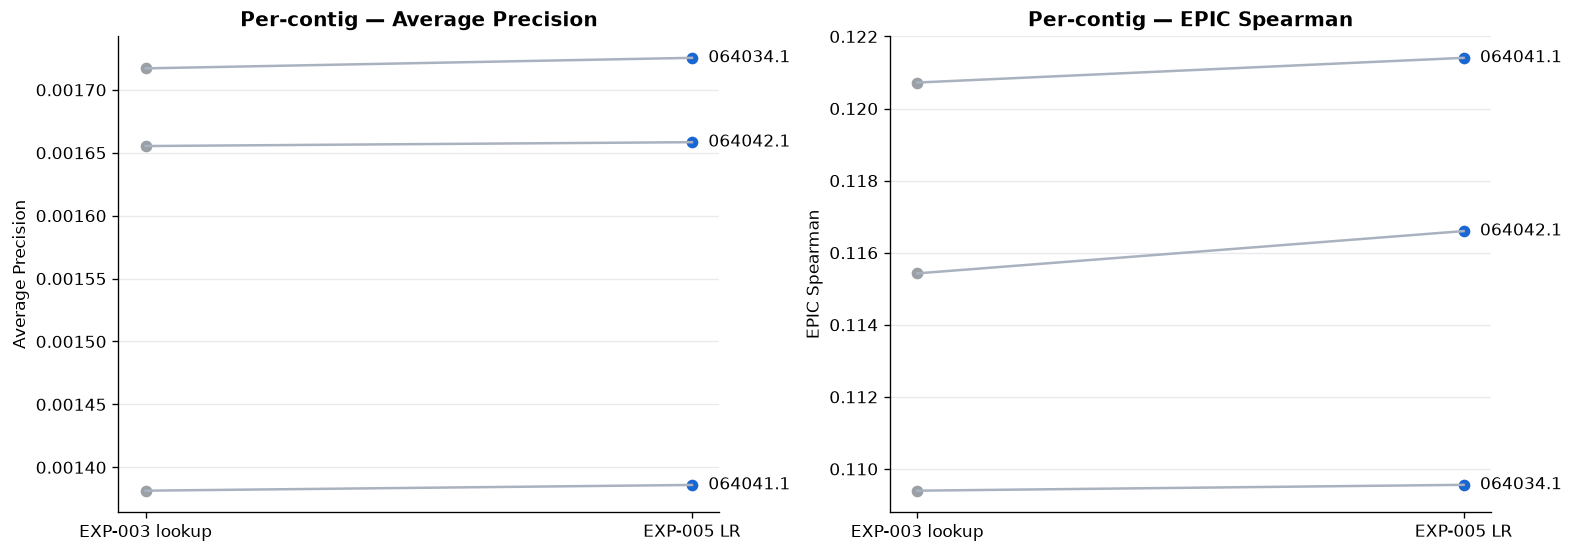

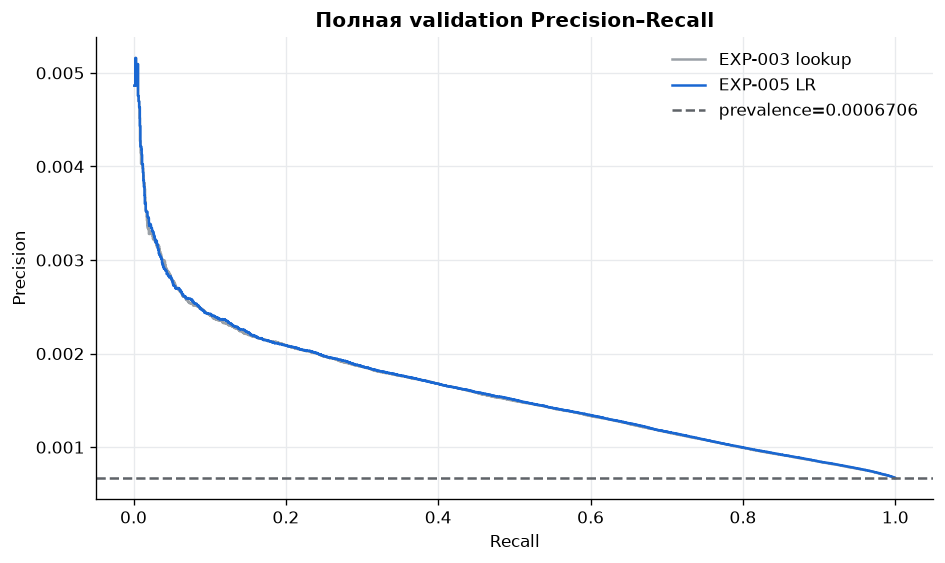

In [28]:
fig_contigs, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for ax, metric, label in [
    (axes[0], "average_precision", "Average Precision"),
    (axes[1], "epic_spearman", "EPIC Spearman"),
]:
    ref = per_contig_metrics[f"reference_{metric}"]
    cand = per_contig_metrics[f"candidate_{metric}"]
    for index, contig in enumerate(per_contig_metrics["contig"]):
        ax.plot([0, 1], [ref.iloc[index], cand.iloc[index]], color="#AAB2C0")
        ax.scatter([0], [ref.iloc[index]], color="#9AA0A6")
        ax.scatter([1], [cand.iloc[index]], color="#1967D2")
        ax.text(1.03, cand.iloc[index], contig.replace("NC_", ""), va="center")
    ax.set_xticks([0, 1], ["EXP-003 lookup", "EXP-005 LR"])
    ax.set_ylabel(label)
    ax.set_title(f"Per-contig — {label}")
    ax.grid(axis="y", color="#E8EAED")
plt.show()

reference_pr = lookup_evaluation.precision_recall.loc[
    lookup_evaluation.precision_recall["k"] == 6
]
candidate_pr = candidate_evaluation.precision_recall
fig_pr, ax = plt.subplots(figsize=(9, 5))
ax.step(reference_pr["recall"], reference_pr["precision"], where="post",
        color="#9AA0A6", label="EXP-003 lookup")
ax.step(candidate_pr["recall"], candidate_pr["precision"], where="post",
        color="#1967D2", label="EXP-005 LR")
ax.axhline(candidate_row["prevalence"], color="#5F6368", linestyle="--",
           label=f"prevalence={candidate_row['prevalence']:.7f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Полная validation Precision–Recall")
ax.legend(frameon=False)
ax.grid(color="#E8EAED")
plt.show()


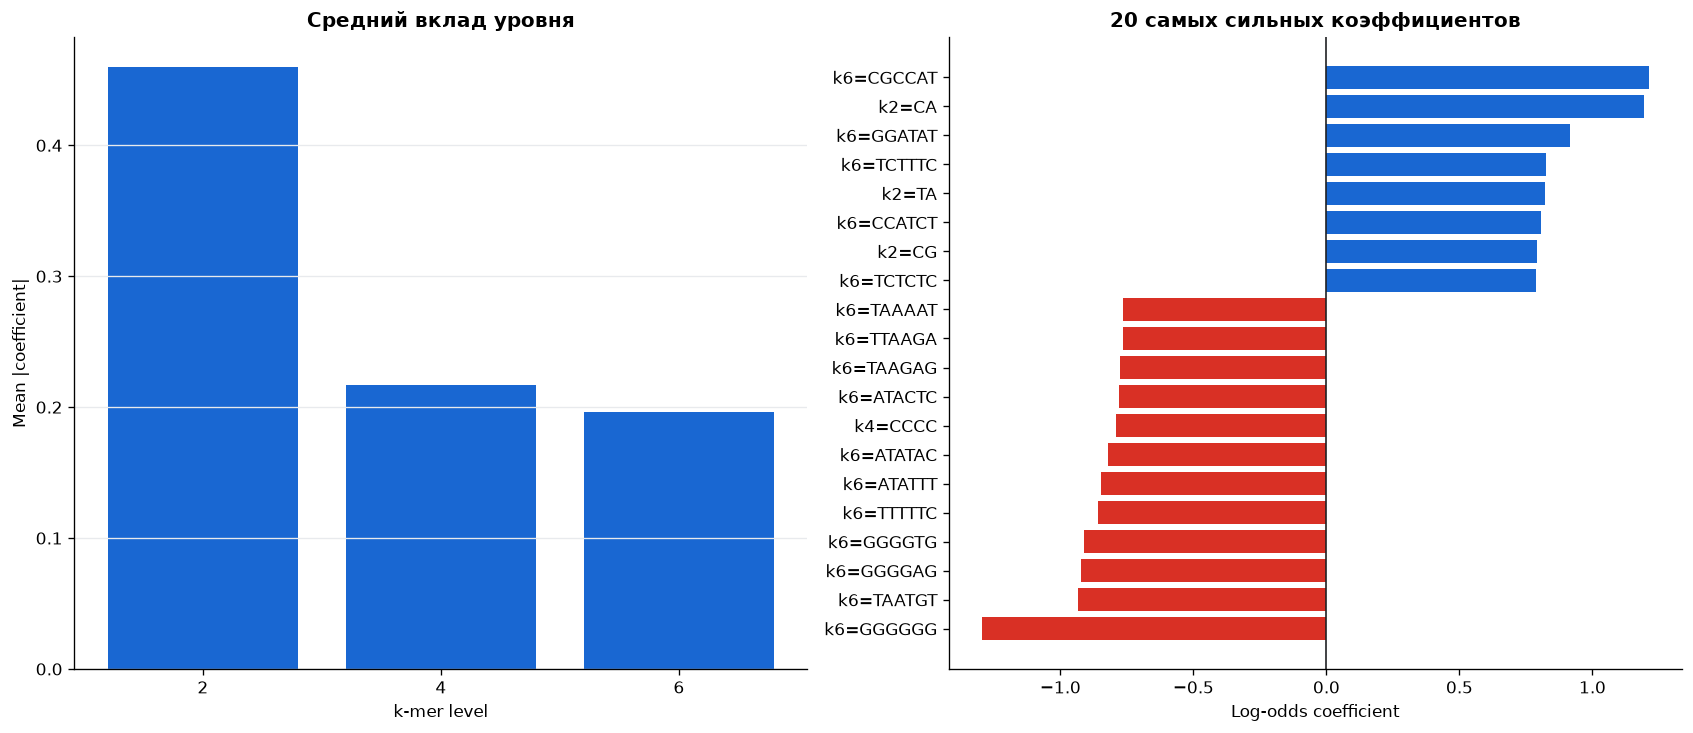

In [29]:
coefficient_summary = (
    final_fit.coefficient_table.groupby("level_k")
    .agg(
        mean_absolute=("absolute_coefficient", "mean"),
        l1_norm=("absolute_coefficient", "sum"),
    )
    .reset_index()
)
strongest = final_fit.coefficient_table.nlargest(
    20, "absolute_coefficient"
).sort_values("coefficient")
fig_coefficients, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
axes[0].bar(
    coefficient_summary["level_k"].astype(str),
    coefficient_summary["mean_absolute"],
    color="#1967D2",
)
axes[0].set_xlabel("k-mer level")
axes[0].set_ylabel("Mean |coefficient|")
axes[0].set_title("Средний вклад уровня")
axes[0].grid(axis="y", color="#E8EAED")
axes[1].barh(
    strongest["feature_name"],
    strongest["coefficient"],
    color=np.where(strongest["coefficient"] >= 0, "#1967D2", "#D93025"),
)
axes[1].axvline(0, color="#202124", linewidth=1)
axes[1].set_xlabel("Log-odds coefficient")
axes[1].set_title("20 самых сильных коэффициентов")
plt.show()


## 10. Механическое решение

Эта ячейка не меняет критерий после просмотра результата. Все три
условия должны выполниться одновременно. Даже хороший train-CV не
заменяет внешний contig holdout.


In [30]:
reference_ap = float(reference_row["average_precision"])
candidate_ap = float(candidate_row["average_precision"])
reference_spearman = float(reference_row["epic_spearman"])
candidate_spearman = float(candidate_row["epic_spearman"])
relative_ap_gain = candidate_ap / reference_ap - 1
contig_ap_wins = int((
    per_contig_metrics["candidate_average_precision"]
    > per_contig_metrics["reference_average_precision"]
).sum())
success_checks = pd.Series({
    "relative AP gain >= 1%": relative_ap_gain >= 0.01,
    "EPIC Spearman >= EXP-003": candidate_spearman >= reference_spearman,
    "AP wins on at least 2/3 contigs": contig_ap_wins >= 2,
}, name="passed")
display(success_checks.to_frame())
DECISION = "adopt" if bool(success_checks.all()) else "reject"
INTERPRETATION = (
    f"Hierarchical LR changed AP from {reference_ap:.9f} to "
    f"{candidate_ap:.9f} ({relative_ap_gain:+.2%}) and EPIC Spearman "
    f"from {reference_spearman:.6f} to {candidate_spearman:.6f}; "
    f"AP wins on {contig_ap_wins}/3 contigs. Decision: {DECISION}."
)
display(Markdown(f"**Decision: `{DECISION}`.** {INTERPRETATION}"))


,passed
relative AP gain >= 1%,False
EPIC Spearman >= EXP-003,True
AP wins on at least 2/3 contigs,True


**Decision: `reject`.** Hierarchical LR changed AP from 0.001600537 to 0.001606098 (+0.35%) and EPIC Spearman from 0.097186 to 0.097569; AP wins on 3/3 contigs. Decision: reject.

## 11. Сохранение — выполнять последней

Ячейка создаёт `artifacts/experiments/EXP-005/run_001`. Она не
перезаписывает существующий run. До проверки decision её запускать
нельзя.


In [31]:
PLOT_DIR.mkdir(parents=True, exist_ok=True)
plot_objects = {
    "01_train_cv_diagnostics.png": fig_cv,
    "02_validation_metrics.png": fig_metrics,
    "03_per_contig_metrics.png": fig_contigs,
    "04_precision_recall.png": fig_pr,
    "05_coefficients.png": fig_coefficients,
}
for filename, figure in plot_objects.items():
    figure.savefig(
        PLOT_DIR / filename,
        dpi=170,
        bbox_inches="tight",
        facecolor="white",
    )
tables = {
    "cv_fold_assignment.csv": fold_assignment,
    "cv_results.csv": cv_results,
    "cv_summary.csv": cv_summary,
    "metric_summary.csv": metric_summary,
    "per_contig_metrics.csv": per_contig_metrics,
    "fit_report.csv": final_fit.fit_report,
    "feature_table.csv": final_fit.design.feature_table,
    "coefficient_table.csv": final_fit.coefficient_table,
    "precision_recall.csv": candidate_evaluation.precision_recall,
}
for filename, table in tables.items():
    table.to_csv(ARTIFACT_DIR / filename, index=False)
candidate_evaluation.positive_predictions.to_csv(
    ARTIFACT_DIR / "positive_predictions.csv.gz",
    index=False,
    compression="gzip",
)

METRICS = {
    "reference_average_precision": reference_ap,
    "candidate_average_precision": candidate_ap,
    "delta_average_precision": candidate_ap - reference_ap,
    "relative_average_precision_gain": relative_ap_gain,
    "reference_epic_spearman": reference_spearman,
    "candidate_epic_spearman": candidate_spearman,
    "delta_epic_spearman": candidate_spearman - reference_spearman,
}
PARAMETERS = CONFIG.to_dict() | {
    "selected_C": SELECTED_C,
    "reference_experiment": "EXP-003/run_001",
    "validation_population": "all whitelist positions",
    "validation_used_for_C_selection": False,
    "score": "raw float64 logistic decision_function",
}
record = build_run_record(
    SPEC,
    split,
    run_name=RUN_NAME,
    notebook_path=NOTEBOOK_PATH,
    parameters=PARAMETERS,
    metrics=METRICS,
    interpretation=INTERPRETATION,
    decision=DECISION,
)
output = save_run_record(PROJECT_ROOT, record)
(output / "config.json").write_text(
    json.dumps(PARAMETERS, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)
print("Saved run:", output)


Saved run: D:\Projects\EPIC\EPIC\artifacts\experiments\EXP-005\run_001


In [ ]:
from ml_project.epic_experiment_report import sync_exp005_report

experiment_note = sync_exp005_report(PROJECT_ROOT, run_name=RUN_NAME)
print("Updated experiment note:", experiment_note)
